In [90]:
import tensorflow as tf
import matplotlib.pyplot as plt 

### Loading the dataset

In [91]:
# Load the image dataset and convert all the image to same size (224x244 / 129x128)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    'D:/Computer-Vision/Dataset',
    subset = 'training',
    seed = 123,
    validation_split = 0.2,         # Train Dataset
    image_size = (224,224),
    batch_size = 32
    )

test_dataset = tf.keras.utils.image_dataset_from_directory(
    'D:\Computer-Vision\Dataset',
    validation_split = 0.2,
    subset = 'validation',
    seed = 123,                     # Test Dataset
    image_size = (224,224),
    batch_size = 32
)

class_names = train_dataset.class_names
print('Class names : \n',class_names)

Found 1000 files belonging to 5 classes.
Using 800 files for training.


Found 1000 files belonging to 5 classes.
Using 200 files for validation.
Class names : 
 ['Bean', 'Broccoli', 'Capsicum', 'Carrot', 'Cauliflower']


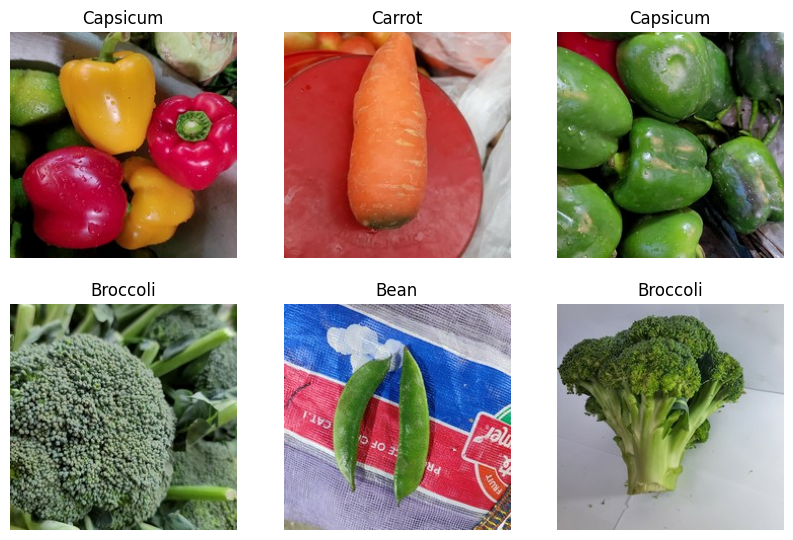

In [92]:
# Viewing the Dataset 

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(6):

        plt.subplot(3, 3, i + 1) # (rows, column , Position[index])

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

### Normalization

In [93]:
# Each image consist of several pixels.
# Each pixel is in form of R G B where each one have values 0~255 , e.g pixel_a = [123,44,233]. 
# Now due to the large range 0~255 , it is hard for a NN to learn faster.
# So we convert 0~255 to 0~1.
# This is normalization.

# We use the formula pixel value x 1/255. eg 128 * 1/255 = 0.502. Hence between range (0~1)

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x,y : (normalization_layer(x),y)
)

test_dataset = test_dataset.map(
    lambda x,y : (normalization_layer(x),y)
)


In [81]:
# Checking normalization success

# for image_batch, labels_batch in train_dataset_normalized.take(1):

#     print(image_batch[0])

### Data Augementation

In [94]:
# So we ourself rotate , flip , zoom training images so model generalize better for real life leaves

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [83]:
# plt.figure(figsize=(10,10))

# for images , labels in test_dataset_normalized.take(1):

#     augmented_image = data_augmentation(images)

#     for i in range(9):
    
#         plt.subplot(3, 3, i + 1)  

#         plt.imshow(augmented_image[i].numpy())

#         plt.axis("off")

# plt.show()
    

### Adding Optimizer for dataset

In [95]:
# Prefetching

# Normally : Load batch → Train → Load next batch ......... This wastes GPU/CPU time.

# Using Prefetch : Train current batch while next batch loads simultaneously .......... Faster training ,Better hardware usage.

AUTOTUNE = tf.data.AUTOTUNE

train_dataset_normalized = train_dataset.prefetch(buffer_size=AUTOTUNE)

test_dataset_normalized = test_dataset.prefetch(buffer_size=AUTOTUNE)

### Creating a CNN model

In [114]:
model = tf.keras.Sequential([
    
    data_augmentation,

    # tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3,3), input_shape = (224,224,3), activation='relu'),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),

    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Conv2D(128 , (3,3), activation='relu'),

    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.GlobalAveragePooling2D(), # Converts vectors matrix that represents a image into one number

    tf.keras.layers.Dense(128, activation='relu'), #Fully connected layer with 128 neurons

    tf.keras.layers.Dense(5, activation='softmax') # Output layer wit 5 probabilites, one for eac class


])


In [117]:
model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [115]:
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

### Training the Model FAHH

In [118]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.3713 - loss: 1.4718 - val_accuracy: 0.3450 - val_loss: 1.2786
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.4800 - loss: 1.1243 - val_accuracy: 0.4850 - val_loss: 1.0870
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5950 - loss: 0.9393 - val_accuracy: 0.6650 - val_loss: 0.8252
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7287 - loss: 0.7200 - val_accuracy: 0.8000 - val_loss: 0.5937
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7725 - loss: 0.5796 - val_accuracy: 0.7650 - val_loss: 0.5317
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7975 - loss: 0.5217 - val_accuracy: 0.7700 - val_loss: 0.5544
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7900 - loss: 0.5161 - val_accuracy: 0.8250 - val_loss: 0.4677
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8363 - loss: 0.4565 - val_accuracy: 0.8150 - val_loss:

### Saving the model

In [119]:
model.save('veggie_classifier.keras')